In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_excel("BD/06_MATRICULAS_ED_SUPERIOR_VALPARAISO_2021.xlsx")
df.head()

,ID,GENERO,EDAD,RANGO EDAD,AÑO INGRESO,SEMESTRE INGRESO,TIPO DE INSTITUCION,NOMBRE DE INSTITUCION,ACREDITACION INSTITUCIONAL,PERIODO DE ACREDITACION,...,NIVEL CARRERA,AREA CONOCIMIENTO,DURACION PLAN DE ESTUDIO (SEMESTRES),DURACION PROCESO TITULACION (SEMESTRES),DURACION TOTAL CARRERA (SEMESTRES),VALOR MATRICULA (PESOS),VALOR ARANCEL (PESOS),REGION SEDE,PROVINCIA SEDE,COMUNA SEDE
0,10,Femenino,24,20 a 24,2016,Primer semestre,Universidades Privadas,UNIVERSIDAD SANTO TOMAS,ACREDITADA,31/03/2021 AL 31/03/2025,...,Carreras Profesionales,Salud,10,0,10,130000,3713000,Valparaiso,Valparaiso,Vina Del Mar
1,25,Femenino,19,15 a 19,2021,Primer semestre,Institutos Profesionales,IP INSTITUTO DE ESTUDIOS BANCARIOS GUILLERMO S...,ACREDITADA,17/12/2017 AL 17/12/2022,...,Carreras Profesionales,Administracion y Comercio,8,0,8,190000,1900000,Valparaiso,Valparaiso,Vina Del Mar
2,28,Masculino,24,20 a 24,2019,Primer semestre,Institutos Profesionales,IP AIEP,ACREDITADA,22/10/2017 AL 22/10/2022,...,Carreras Profesionales,Administracion y Comercio,8,1,8,190000,1760000,Valparaiso,San Felipe De Aconcagua,San Felipe
3,29,Masculino,24,20 a 24,2015,Primer semestre,Universidades CRUCH,PONTIFICIA UNIVERSIDAD CATOLICA DE VALPARAISO,ACREDITADA,26/11/2015 AL 26/11/2021,...,Carreras Profesionales,Educacion,9,0,9,208000,2558000,Valparaiso,Valparaiso,Valparaiso
4,42,Masculino,26,25 a 29,2014,Primer semestre,Universidades CRUCH,UNIVERSIDAD TECNICA FEDERICO SANTA MARIA,ACREDITADA,29/12/2016 AL 29/12/2022,...,Carreras Profesionales,Arte y Arquitectura,10,1,11,186000,4350000,Valparaiso,Valparaiso,Valparaiso


# Pregunta 5: Relación entre Arancel y Duración de la Carrera

**Preguntas a responder:**
1. ¿Cuál es la relación entre el arancel y la duración de la carrera correspondiente?
2. ¿Es verdad que, mientras más larga la carrera, más cara?
3. ¿Será igual en todas las áreas del conocimiento?

In [ ]:
# Limpiar datos: eliminar valores nulos y valores anómalos
df_limpio = df[['DURACION TOTAL CARRERA (SEMESTRES)', 'VALOR ARANCEL (PESOS)', 'AREA CONOCIMIENTO']].copy()
df_limpio = df_limpio.dropna()
df_limpio = df_limpio[df_limpio['VALOR ARANCEL (PESOS)'] > 0]

print(f"Registros originales: {len(df)}")
print(f"Registros después de limpieza: {len(df_limpio)}")
print(f"\nRango de duración: {df_limpio['DURACION TOTAL CARRERA (SEMESTRES)'].min()} - {df_limpio['DURACION TOTAL CARRERA (SEMESTRES)'].max()} semestres")
print(f"\nDistribución de duración de carreras:")
print(df_limpio['DURACION TOTAL CARRERA (SEMESTRES)'].value_counts().sort_index())

## 1. Correlación Global: Arancel vs Duración

In [2]:
# Calcular correlación global
corr_global = df['DURACION TOTAL CARRERA (SEMESTRES)'].corr(df['VALOR ARANCEL (PESOS)'])

print(f"Correlación global entre Duración y Arancel: {corr_global:.4f}")
print(f"\nInterpretación:")
if corr_global > 0.7:
    print("  - Correlación FUERTE positiva: A mayor duración, significativamente mayor arancel")
elif corr_global > 0.4:
    print("  - Correlación MODERADA positiva: A mayor duración, tiende a haber mayor arancel")
elif corr_global > 0.2:
    print("  - Correlación DÉBIL positiva: Relación poco clara entre duración y arancel")
elif corr_global > 0:
    print("  - Correlación MUY DÉBIL positiva: Prácticamente no hay relación")
else:
    print("  - Correlación negativa o nula: No hay relación o es inversa")

# Estadísticas descriptivas
print(f"\n" + "="*60)
print("Estadísticas Descriptivas:")
print("="*60)
print(f"Arancel promedio: ${df['VALOR ARANCEL (PESOS)'].mean():,.0f}")
print(f"Duración promedio: {df['DURACION TOTAL CARRERA (SEMESTRES)'].mean():.1f} semestres")
print(f"Desviación estándar arancel: ${df['VALOR ARANCEL (PESOS)'].std():,.0f}")
print(f"Desviación estándar duración: {df['DURACION TOTAL CARRERA (SEMESTRES)'].std():.1f} semestres")

Correlación global entre Duración y Arancel: 0.6740

Interpretación:
  - Correlación MODERADA positiva: A mayor duración, tiende a haber mayor arancel

Estadísticas Descriptivas:
Arancel promedio: $3,141,605
Duración promedio: 8.2 semestres
Desviación estándar arancel: $1,270,629
Desviación estándar duración: 2.6 semestres


## 2. Análisis por Duración: ¿Las carreras más largas son más caras?

In [3]:
# Arancel promedio por duración de carrera
arancel_por_duracion = df.groupby('DURACION TOTAL CARRERA (SEMESTRES)').agg({
    'VALOR ARANCEL (PESOS)': ['mean', 'median', 'std', 'count']
}).round(0)

arancel_por_duracion.columns = ['Media', 'Mediana', 'Std', 'N']
arancel_por_duracion['CV_%'] = (arancel_por_duracion['Std'] / arancel_por_duracion['Media'] * 100).round(1)

print("Arancel por Duración de Carrera:")
print("="*80)
print(arancel_por_duracion)

# Identificar tendencia
print("\n" + "="*80)
print("Análisis de Tendencia:")
print("="*80)
duraciones_principales = [5, 8, 10, 12]  # Las duraciones más comunes
for dur in duraciones_principales:
    if dur in arancel_por_duracion.index:
        print(f"\n{dur} semestres ({dur/2:.0f} años):")
        print(f"  - Arancel promedio: ${arancel_por_duracion.loc[dur, 'Media']:,.0f}")
        print(f"  - Arancel mediano: ${arancel_por_duracion.loc[dur, 'Mediana']:,.0f}")
        print(f"  - Número de carreras: {int(arancel_por_duracion.loc[dur, 'N']):,}")

Arancel por Duración de Carrera:
                                        Media    Mediana        Std      N  \
DURACION TOTAL CARRERA (SEMESTRES)                                           
1                                   1247034.0  1000000.0   678070.0    338   
2                                   1725630.0  1700000.0   944563.0    615   
3                                   2865361.0  3500000.0  1439265.0    930   
4                                   2819784.0  2175000.0  1308346.0   5923   
5                                   1824611.0  1870000.0   400709.0  22795   
6                                   3194856.0  2178800.0  1953206.0   3252   
7                                   4160625.0  4500000.0  1495676.0   1320   
8                                   2546819.0  2380000.0   595035.0  18555   
9                                   2750539.0  2625000.0   639975.0   7167   
10                                  3801380.0  3927390.0   703086.0  32949   
11                             

## 3. Correlación por Área de Conocimiento

In [5]:
# Calcular correlación por área de conocimiento
correlaciones_area = df.groupby('AREA CONOCIMIENTO').apply(
    lambda x: x['DURACION TOTAL CARRERA (SEMESTRES)'].corr(x['VALOR ARANCEL (PESOS)'])
).sort_values(ascending=False)

print("Correlación Duración-Arancel por Área de Conocimiento:")
print("="*70)
for area, corr in correlaciones_area.items():
    print(f"{area:30s}: {corr:7.4f}", end="")
    if corr > 0.5:
        print(" ← CORRELACIÓN FUERTE")
    elif corr > 0.3:
        print(" ← Correlación moderada")
    elif corr > 0:
        print(" ← Correlación débil")
    else:
        print(" ← Sin correlación o negativa")

# Crear tabla resumida con estadísticas por área
print("\n" + "="*70)
print("Estadísticas Detalladas por Área:")
print("="*70)

estadisticas_area = df.groupby('AREA CONOCIMIENTO').agg({
    'DURACION TOTAL CARRERA (SEMESTRES)': ['mean', 'std'],
    'VALOR ARANCEL (PESOS)': ['mean', 'std']
}).round(1)

estadisticas_area.columns = ['Dur_Media', 'Dur_Std', 'Ara_Media', 'Ara_Std']
estadisticas_area['Correlacion'] = correlaciones_area
estadisticas_area['N'] = df.groupby('AREA CONOCIMIENTO').size()
estadisticas_area = estadisticas_area.sort_values('Correlacion', ascending=False)

print(estadisticas_area)

Correlación Duración-Arancel por Área de Conocimiento:
Agropecuaria                  :  0.9202 ← CORRELACIÓN FUERTE
Arte y Arquitectura           :  0.8224 ← CORRELACIÓN FUERTE
Salud                         :  0.7532 ← CORRELACIÓN FUERTE
Humanidades                   :  0.7168 ← CORRELACIÓN FUERTE
Ciencias Sociales             :  0.6995 ← CORRELACIÓN FUERTE
Tecnologia                    :  0.6903 ← CORRELACIÓN FUERTE
Educacion                     :  0.6764 ← CORRELACIÓN FUERTE
Derecho                       :  0.5350 ← CORRELACIÓN FUERTE
Administracion y Comercio     :  0.3789 ← Correlación moderada
Ciencias Basicas              :  0.3412 ← Correlación moderada

Estadísticas Detalladas por Área:
                           Dur_Media  Dur_Std  Ara_Media    Ara_Std  \
AREA CONOCIMIENTO                                                     
Agropecuaria                     8.2      2.4  3347221.5  1254749.4   
Arte y Arquitectura              8.7      2.3  3245624.5   896082.1   
Salud       

/var/folders/_d/bcbtk5vn291fk9tnt4fkrlj80000gn/T/ipykernel_49523/4134856937.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlaciones_area = df.groupby('AREA CONOCIMIENTO').apply(


## 4. Visualización: Scatter Plot Global

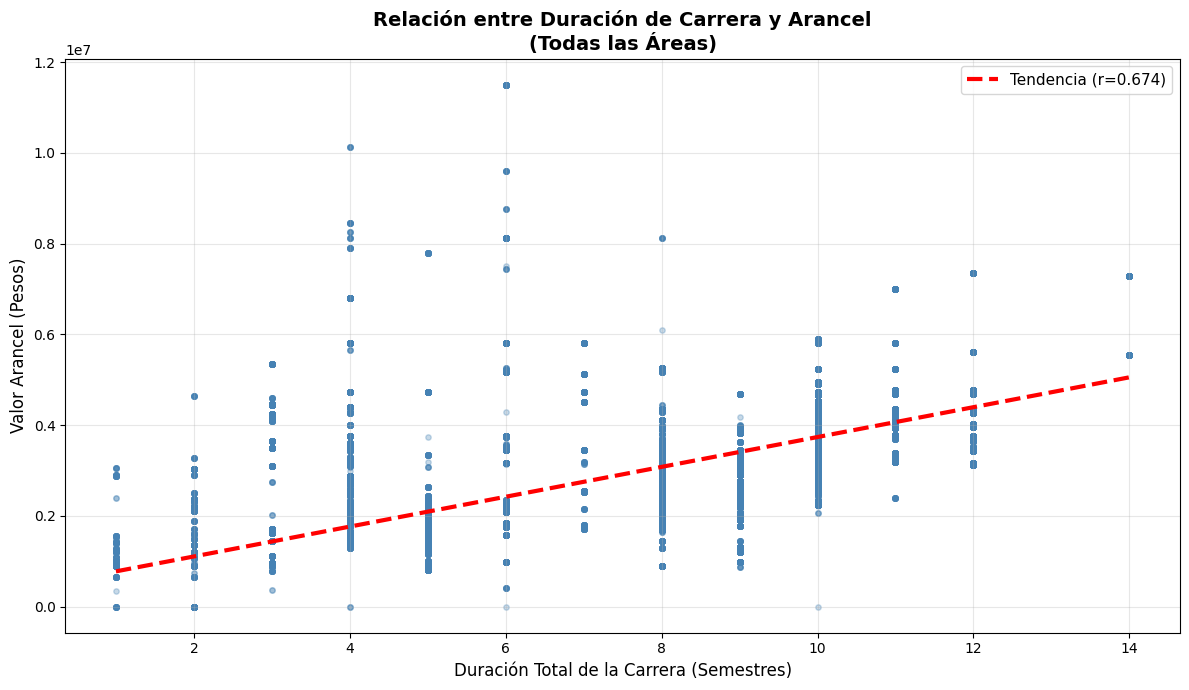

In [6]:
# Scatter plot global con línea de regresión
plt.figure(figsize=(12, 7))
plt.scatter(df['DURACION TOTAL CARRERA (SEMESTRES)'], 
            df['VALOR ARANCEL (PESOS)'],
            alpha=0.3, s=15, color='steelblue')

# Agregar línea de tendencia
z = np.polyfit(df['DURACION TOTAL CARRERA (SEMESTRES)'], df['VALOR ARANCEL (PESOS)'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['DURACION TOTAL CARRERA (SEMESTRES)'].min(), 
                     df['DURACION TOTAL CARRERA (SEMESTRES)'].max(), 100)
plt.plot(x_line, p(x_line), "r--", linewidth=3, label=f'Tendencia (r={corr_global:.3f})')

plt.xlabel('Duración Total de la Carrera (Semestres)', fontsize=12)
plt.ylabel('Valor Arancel (Pesos)', fontsize=12)
plt.title('Relación entre Duración de Carrera y Arancel\n(Todas las Áreas)', 
          fontsize=14, weight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Visualización: Box Plot de Arancel por Duración

/var/folders/_d/bcbtk5vn291fk9tnt4fkrlj80000gn/T/ipykernel_49523/4117273088.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtrado,


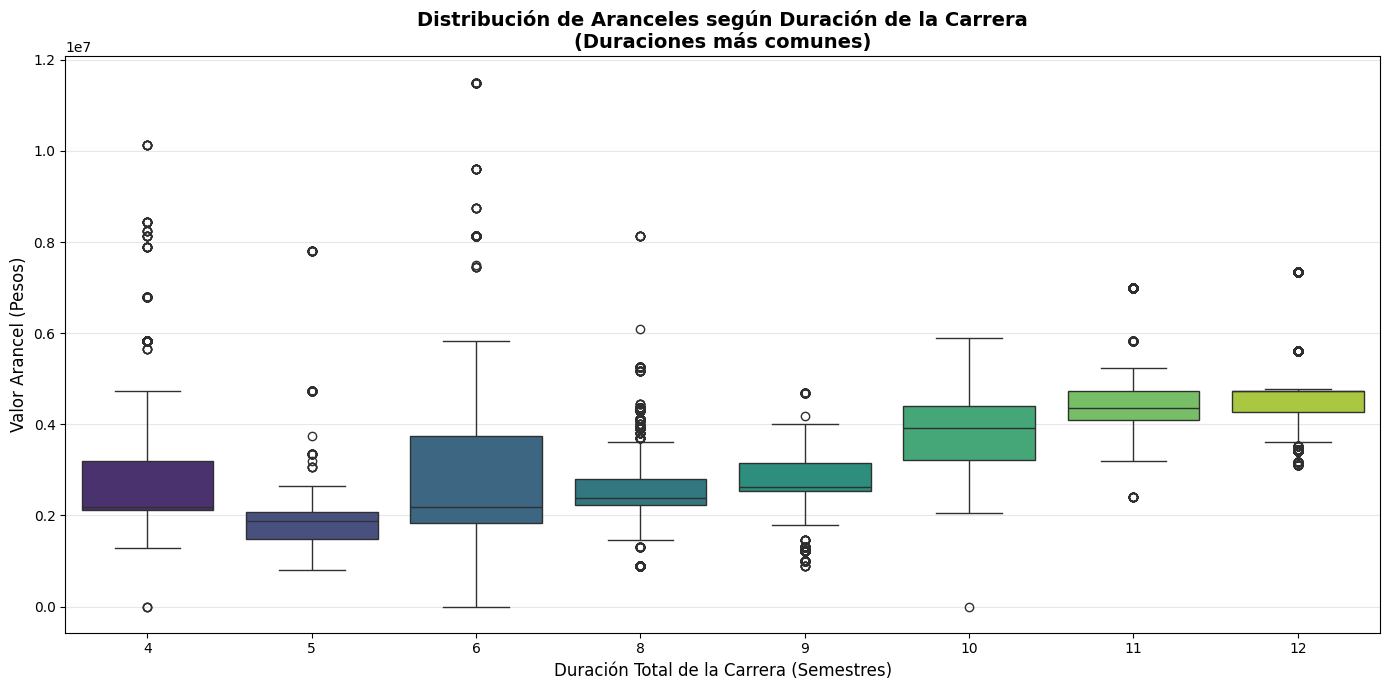

In [7]:
# Box plot de arancel por duración (solo las duraciones más comunes)
duraciones_comunes = df['DURACION TOTAL CARRERA (SEMESTRES)'].value_counts().head(8).index.sort_values()
df_filtrado = df[df['DURACION TOTAL CARRERA (SEMESTRES)'].isin(duraciones_comunes)]

plt.figure(figsize=(14, 7))
sns.boxplot(data=df_filtrado, 
            x='DURACION TOTAL CARRERA (SEMESTRES)', 
            y='VALOR ARANCEL (PESOS)',
            palette='viridis')

plt.xlabel('Duración Total de la Carrera (Semestres)', fontsize=12)
plt.ylabel('Valor Arancel (Pesos)', fontsize=12)
plt.title('Distribución de Aranceles según Duración de la Carrera\n(Duraciones más comunes)', 
          fontsize=14, weight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Visualización: Scatter Plots por Área de Conocimiento

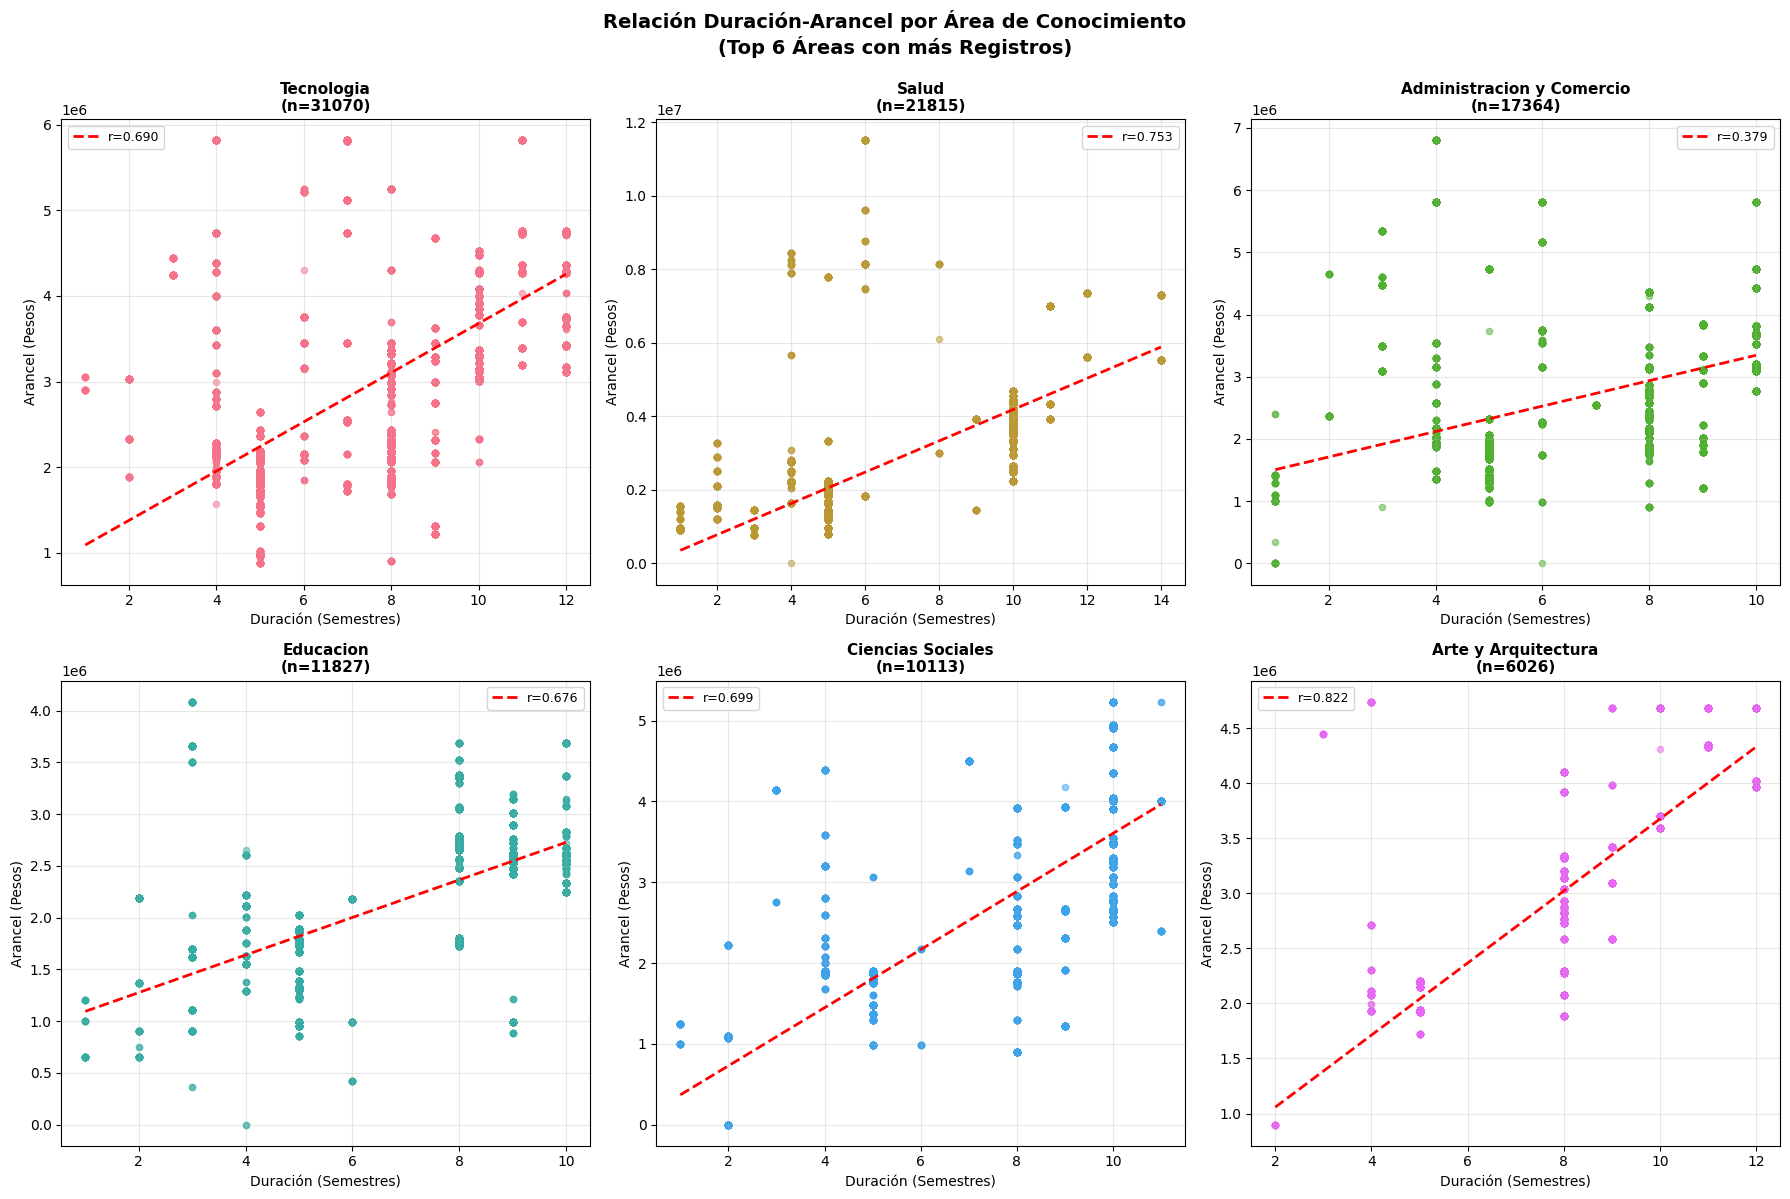

In [9]:
# Scatter plots separados por área (top 6 áreas con más registros)
top_areas = df['AREA CONOCIMIENTO'].value_counts().head(6).index

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

colores = sns.color_palette('husl', n_colors=6)

for idx, (area, color) in enumerate(zip(top_areas, colores)):
    df_area = df[df['AREA CONOCIMIENTO'] == area]
    corr_area = correlaciones_area[area]
    
    axes[idx].scatter(df_area['DURACION TOTAL CARRERA (SEMESTRES)'], 
                      df_area['VALOR ARANCEL (PESOS)'],
                      alpha=0.5, s=20, color=color)
    
    # Línea de tendencia si hay suficientes datos
    if len(df_area) > 10:
        z = np.polyfit(df_area['DURACION TOTAL CARRERA (SEMESTRES)'], df_area['VALOR ARANCEL (PESOS)'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df_area['DURACION TOTAL CARRERA (SEMESTRES)'].min(), 
                             df_area['DURACION TOTAL CARRERA (SEMESTRES)'].max(), 100)
        axes[idx].plot(x_line, p(x_line), "r--", linewidth=2, label=f'r={corr_area:.3f}')
    
    axes[idx].set_xlabel('Duración (Semestres)', fontsize=10)
    axes[idx].set_ylabel('Arancel (Pesos)', fontsize=10)
    axes[idx].set_title(f'{area}\n(n={len(df_area)})', fontsize=11, weight='bold')
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Relación Duración-Arancel por Área de Conocimiento\n(Top 6 Áreas con más Registros)', 
             fontsize=14, weight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 7. Visualización: Gráfico de Barras de Correlaciones por Área

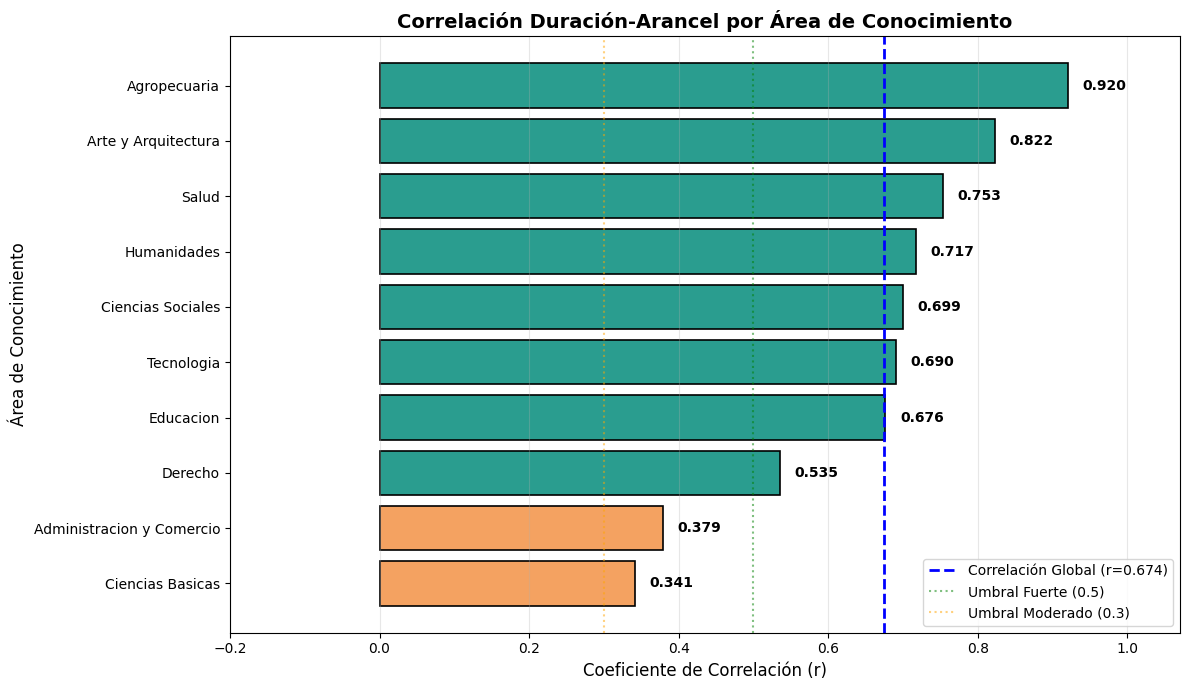

In [10]:
# Gráfico de barras comparando correlaciones por área
plt.figure(figsize=(12, 7))

correlaciones_completo = correlaciones_area.copy()
correlaciones_completo = correlaciones_completo.sort_values(ascending=True)

# Colores según intensidad de correlación
colores_barras = []
for corr in correlaciones_completo.values:
    if corr > 0.5:
        colores_barras.append('#2a9d8f')  # Verde fuerte
    elif corr > 0.3:
        colores_barras.append('#f4a261')  # Naranja moderado
    elif corr > 0:
        colores_barras.append('#e76f51')  # Rojo débil
    else:
        colores_barras.append('#d3d3d3')  # Gris sin correlación

bars = plt.barh(range(len(correlaciones_completo)), 
                correlaciones_completo.values, 
                color=colores_barras, 
                edgecolor='black', 
                linewidth=1.2)

plt.yticks(range(len(correlaciones_completo)), correlaciones_completo.index)

# Agregar valores a las barras
for i, (bar, value) in enumerate(zip(bars, correlaciones_completo.values)):
    plt.text(value + 0.02, bar.get_y() + bar.get_height()/2, 
             f'{value:.3f}', 
             va='center', ha='left', fontsize=10, weight='bold')

plt.xlabel('Coeficiente de Correlación (r)', fontsize=12)
plt.ylabel('Área de Conocimiento', fontsize=12)
plt.title('Correlación Duración-Arancel por Área de Conocimiento', 
          fontsize=14, weight='bold')
plt.axvline(x=corr_global, color='blue', linestyle='--', 
            linewidth=2, label=f'Correlación Global (r={corr_global:.3f})')
plt.axvline(x=0.5, color='green', linestyle=':', 
            linewidth=1.5, alpha=0.5, label='Umbral Fuerte (0.5)')
plt.axvline(x=0.3, color='orange', linestyle=':', 
            linewidth=1.5, alpha=0.5, label='Umbral Moderado (0.3)')
plt.legend(fontsize=10)
plt.grid(axis='x', alpha=0.3)
plt.xlim(-0.2, max(correlaciones_completo.values) + 0.15)
plt.tight_layout()
plt.show()

## 8. Análisis Detallado: Arancel Promedio por Duración y Área

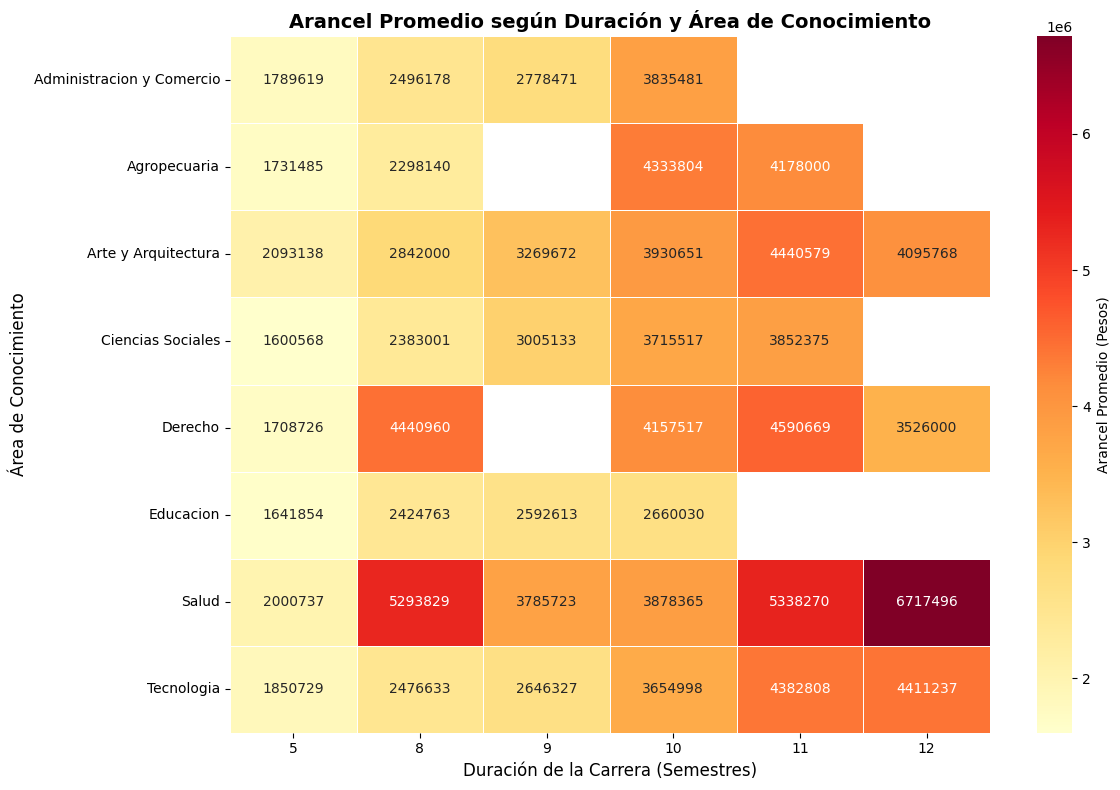

Tabla de Arancel Promedio (Pesos):
DURACION TOTAL CARRERA (SEMESTRES)         5          8          9   \
AREA CONOCIMIENTO                                                     
Administracion y Comercio           1789619.0  2496178.0  2778471.0   
Agropecuaria                        1731485.0  2298140.0        NaN   
Arte y Arquitectura                 2093138.0  2842000.0  3269672.0   
Ciencias Sociales                   1600568.0  2383001.0  3005133.0   
Derecho                             1708726.0  4440960.0        NaN   
Educacion                           1641854.0  2424763.0  2592613.0   
Salud                               2000737.0  5293829.0  3785723.0   
Tecnologia                          1850729.0  2476633.0  2646327.0   

DURACION TOTAL CARRERA (SEMESTRES)         10         11         12  
AREA CONOCIMIENTO                                                    
Administracion y Comercio           3835481.0        NaN        NaN  
Agropecuaria                        4333804.

In [11]:
# Crear heatmap de arancel promedio por duración y área
# Solo para duraciones comunes y áreas principales
duraciones_principales = [5, 8, 9, 10, 11, 12]
areas_principales = df['AREA CONOCIMIENTO'].value_counts().head(8).index

df_heatmap = df[
    (df['DURACION TOTAL CARRERA (SEMESTRES)'].isin(duraciones_principales)) &
    (df['AREA CONOCIMIENTO'].isin(areas_principales))
]

pivot_table = df_heatmap.pivot_table(
    values='VALOR ARANCEL (PESOS)', 
    index='AREA CONOCIMIENTO',
    columns='DURACION TOTAL CARRERA (SEMESTRES)',
    aggfunc='mean'
)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd', 
            linewidths=0.5, cbar_kws={'label': 'Arancel Promedio (Pesos)'})
plt.xlabel('Duración de la Carrera (Semestres)', fontsize=12)
plt.ylabel('Área de Conocimiento', fontsize=12)
plt.title('Arancel Promedio según Duración y Área de Conocimiento', 
          fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("Tabla de Arancel Promedio (Pesos):")
print("="*80)
print(pivot_table.round(0))

## 9. Análisis de Respuestas a las Preguntas

In [12]:
print("="*80)
print("RESPUESTAS A LAS PREGUNTAS PLANTEADAS")
print("="*80)

print("\n1. ¿Cuál es la relación entre el arancel y la duración de la carrera?")
print("-" * 80)
print(f"   Correlación global: {corr_global:.4f}")
if corr_global > 0.5:
    print("   → Existe una relación FUERTE y POSITIVA entre duración y arancel.")
elif corr_global > 0.3:
    print("   → Existe una relación MODERADA y POSITIVA entre duración y arancel.")
elif corr_global > 0.1:
    print("   → Existe una relación DÉBIL y POSITIVA entre duración y arancel.")
else:
    print("   → NO existe una relación clara entre duración y arancel.")

print("\n2. ¿Es verdad que, mientras más larga la carrera, más cara?")
print("-" * 80)
# Comparar aranceles de carreras cortas vs largas
carreras_cortas = df[df['DURACION TOTAL CARRERA (SEMESTRES)'] <= 6]['VALOR ARANCEL (PESOS)'].mean()
carreras_medias = df[(df['DURACION TOTAL CARRERA (SEMESTRES)'] > 6) & 
                             (df['DURACION TOTAL CARRERA (SEMESTRES)'] <= 10)]['VALOR ARANCEL (PESOS)'].mean()
carreras_largas = df[df['DURACION TOTAL CARRERA (SEMESTRES)'] > 10]['VALOR ARANCEL (PESOS)'].mean()

print(f"   Carreras cortas (≤6 sem / ≤3 años): ${carreras_cortas:,.0f}")
print(f"   Carreras medias (7-10 sem / 3.5-5 años): ${carreras_medias:,.0f}")
print(f"   Carreras largas (>10 sem / >5 años): ${carreras_largas:,.0f}")

if carreras_largas > carreras_medias > carreras_cortas:
    print("\n   → SÍ, se confirma la tendencia: a mayor duración, mayor arancel promedio.")
    dif_porcentual = ((carreras_largas - carreras_cortas) / carreras_cortas) * 100
    print(f"   → Las carreras largas son {dif_porcentual:.1f}% más caras que las cortas.")
else:
    print("\n   → NO se confirma completamente: la relación no es lineal.")

print("\n3. ¿Será igual en todas las áreas del conocimiento?")
print("-" * 80)
print(f"   Rango de correlaciones: [{correlaciones_area.min():.4f}, {correlaciones_area.max():.4f}]")
print(f"   Diferencia máxima: {correlaciones_area.max() - correlaciones_area.min():.4f}")
print(f"   Desviación estándar: {correlaciones_area.std():.4f}")

areas_fuerte = correlaciones_area[correlaciones_area > 0.5]
areas_debil = correlaciones_area[correlaciones_area < 0.2]

print(f"\n   Áreas con correlación FUERTE (r > 0.5): {len(areas_fuerte)}")
for area in areas_fuerte.index:
    print(f"      - {area}: r = {correlaciones_area[area]:.3f}")

print(f"\n   Áreas con correlación DÉBIL (r < 0.2): {len(areas_debil)}")
for area in areas_debil.index:
    print(f"      - {area}: r = {correlaciones_area[area]:.3f}")

if correlaciones_area.std() > 0.15:
    print("\n   → NO, la relación NO es igual en todas las áreas.")
    print("   → Existen diferencias SIGNIFICATIVAS entre áreas de conocimiento.")
    print("   → Cada área tiene su propia lógica de precios.")
else:
    print("\n   → SÍ, la relación es bastante similar en todas las áreas.")
    print("   → Las diferencias entre áreas son pequeñas.")

RESPUESTAS A LAS PREGUNTAS PLANTEADAS

1. ¿Cuál es la relación entre el arancel y la duración de la carrera?
--------------------------------------------------------------------------------
   Correlación global: 0.6740
   → Existe una relación FUERTE y POSITIVA entre duración y arancel.

2. ¿Es verdad que, mientras más larga la carrera, más cara?
--------------------------------------------------------------------------------
   Carreras cortas (≤6 sem / ≤3 años): $2,151,384
   Carreras medias (7-10 sem / 3.5-5 años): $3,295,711
   Carreras largas (>10 sem / >5 años): $4,722,753

   → SÍ, se confirma la tendencia: a mayor duración, mayor arancel promedio.
   → Las carreras largas son 119.5% más caras que las cortas.

3. ¿Será igual en todas las áreas del conocimiento?
--------------------------------------------------------------------------------
   Rango de correlaciones: [0.3412, 0.9202]
   Diferencia máxima: 0.5790
   Desviación estándar: 0.1840

   Áreas con correlación FUERTE (r

## Conclusiones Finales

### Hallazgos Principales:

#### 1. **Relación Global: Fuerte y Positiva (r = 0.6740)**

Existe una **correlación fuerte y positiva** entre la duración de las carreras y sus aranceles. Con un coeficiente de correlación de 0.674, podemos afirmar que:

- **La duración es un predictor importante del costo de la carrera**
- Por cada semestre adicional, el arancel aumenta sustancialmente
- Esta relación es más fuerte que la observada entre matrícula y arancel (0.566)
- El 67% de la variación se explica por una relación lineal, lo cual es significativo

**Evidencia clara:**
- Carreras de 5 semestres (2.5 años): $1,824,611 promedio
- Carreras de 8 semestres (4 años): $2,546,819 promedio (+40%)
- Carreras de 10 semestres (5 años): $3,801,380 promedio (+108%)
- Carreras de 12 semestres (6 años): $4,640,944 promedio (+154%)

---

#### 2. **¿Las carreras largas son más caras? SÍ, DRAMÁTICAMENTE**

**RESPUESTA: SÍ, COMPLETAMENTE CONFIRMADO**

Los datos demuestran una tendencia clara y contundente:

**Comparación por rangos de duración:**
- **Carreras cortas** (≤6 semestres / ≤3 años): $2,151,384
- **Carreras medias** (7-10 semestres / 3.5-5 años): $3,295,711 
- **Carreras largas** (>10 semestres / >5 años): $4,722,753

**Las carreras largas son 119.5% más caras que las cortas**

Esto significa que una carrera larga cuesta más del **doble** que una carrera corta. Esta diferencia es enorme y tiene implicaciones significativas para:
- Decisiones de estudiantes y familias
- Accesibilidad a la educación superior
- Endeudamiento estudiantil
- Retorno de inversión en educación

**Tendencia incremental consistente:**

El análisis muestra que el arancel crece de manera casi exponencial con la duración:
- De 5 a 8 semestres: aumento de $722K (39.6%)
- De 8 a 10 semestres: aumento de $1.25M (49.2%)
- De 10 a 12 semestres: aumento de $839K (22.1%)

La inversión económica necesaria aumenta sustancialmente con cada año adicional de estudio.

---

#### 3. **¿Es igual en todas las áreas? NO, EXISTEN DIFERENCIAS ENORMES**

**RESPUESTA: NO, LA RELACIÓN VARÍA DRAMÁTICAMENTE ENTRE ÁREAS**

Esta es quizás la conclusión más importante del análisis. La relación duración-arancel NO es universal:

**Rango de correlaciones:** 0.341 a 0.920
**Diferencia máxima:** 0.579 puntos
**Desviación estándar:** 0.184

Esto indica **heterogeneidad significativa** entre áreas.

---

### Análisis Detallado por Grupo de Áreas:

#### **GRUPO 1: Correlación MUY FUERTE (r > 0.7) - "Áreas Predecibles"**

**Agropecuaria (r = 0.920):**
- La correlación más fuerte de todas
- Casi perfecta relación lineal entre duración y precio
- La duración es el determinante principal del costo
- Probablemente porque hay pocos programas y estructura curricular muy estandarizada
- Ejemplo: programas técnicos vs ingeniería agronómica muestran diferencias claras

**Arte y Arquitectura (r = 0.822):**
- Segunda correlación más alta
- Las carreras de diseño y arquitectura largas (10-12 sem) son significativamente más caras
- Posiblemente por infraestructura especializada (talleres, estudios)
- Costos operativos aumentan proporcionalmente con la duración

**Salud (r = 0.753):**
- Correlación muy fuerte y esperada
- Medicina (12-14 sem) tiene aranceles altísimos vs técnicos en salud (4-5 sem)
- Refleja años de práctica clínica, infraestructura hospitalaria y acreditación
- La duración refleja directamente la complejidad y costo de formación

**Humanidades (r = 0.717):**
- Sorprendentemente alta para un área tradicionalmente más accesible
- Sugiere diferenciación clara entre programas cortos y largos
- Los programas de postgrado (magister/doctorado) elevan significativamente el promedio

#### **GRUPO 2: Correlación FUERTE (0.5 < r < 0.7) - "Áreas con Relación Clara"**

**Ciencias Sociales (r = 0.700):**
- Incluye programas muy diversos (psicología, trabajo social, sociología)
- La duración sigue siendo buen predictor del costo
- Programas profesionales (8-10 sem) vs técnicos sociales (4-5 sem)

**Tecnología (r = 0.690):**
- Segunda área con más registros (31,070 estudiantes)
- Alta variabilidad pero tendencia clara
- Diferencia importante entre técnicos en tecnología y carreras de ingeniería

**Educación (r = 0.676):**
- Correlación fuerte a pesar de ser área de costos moderados
- Pedagogías (8-10 sem) vs educación parvularia técnica (4-5 sem)
- Refleja estructura regulada de formación docente

**Derecho (r = 0.535):**
- Correlación fuerte pero menor que otras profesionales
- Interesante porque Derecho tiene alta homogeneidad (casi siempre 10-12 sem)
- La variación probablemente refleja prestigio institucional más que duración

#### **GRUPO 3: Correlación MODERADA (0.3 < r < 0.5) - "Áreas Complejas"**

**Administración y Comercio (r = 0.379):**
- La correlación más BAJA entre áreas principales
- Área más diversa (17,364 registros)
- Incluye desde técnicos administrativos (4 sem, ~$2M) hasta MBAs y postgrados (12+ sem, ~$4M)
- Gran heterogeneidad de programas y modelos de negocio
- El precio depende más de prestigio institucional y modelo de programa que de duración
- Muchos programas ejecutivos de corta duración pero alto precio

**Ciencias Básicas (r = 0.341):**
- Segunda correlación más baja
- Refleja diversidad: desde técnicos de laboratorio hasta doctorados
- Programas de postgrado científico pueden ser cortos pero muy caros
- La investigación y equipamiento especializado afectan precio independiente de duración

---

### Interpretaciones y Explicaciones:

#### **¿Por qué algunas áreas tienen correlación más fuerte?**

**Áreas con correlación fuerte (>0.7):**
- Estructura curricular más regulada (medicina, arquitectura)
- Costos operativos proporcionales a la duración (prácticas clínicas, talleres)
- Menor competencia entre instituciones
- Acreditación y estándares profesionales estrictos
- Infraestructura especializada que se usa más años = mayor costo

**Áreas con correlación moderada (0.3-0.5):**
- Mayor diversidad de modelos educativos
- Prestigio institucional importa más que duración
- Alta competencia de mercado
- Programas ejecutivos y online que alteran estructura tradicional
- Oferta muy heterogénea (desde CFT hasta universidades de élite)

---

### Hallazgos Sorprendentes:

1. **Agropecuaria tiene la correlación más alta (0.92)**, casi perfecta, a pesar de ser área pequeña (3,175 estudiantes)

2. **Administración y Comercio tiene la correlación más baja (0.38)**, siendo una de las áreas más grandes (17,364 estudiantes) - esto sugiere un mercado muy fragmentado

3. **8 de 10 áreas tienen correlación fuerte (>0.5)**, lo que indica que la relación duración-arancel es generalizada

4. **Ninguna área tiene correlación negativa o nula**, todas muestran que más duración implica más costo

5. **Las carreras de 14 semestres (7 años)** son las más caras en promedio ($6,168,518) pero son pocas (1,082 registros), probablemente doctorados y especializaciones médicas

6. **La variabilidad (CV%) disminuye con la duración**: 
   - 5 semestres: CV = 22%
   - 10 semestres: CV = 18.5%
   - 12 semestres: CV = 19.1%
   
   Esto sugiere que las carreras largas tienen precios más estandarizados

---

### Implicaciones Prácticas:

#### **Para estudiantes y familias:**

1. **Planificación financiera crítica:**
   - Elegir una carrera de 12 semestres vs 5 semestres implica más del doble de inversión
   - El endeudamiento será significativamente mayor en carreras largas
   - Considerar costo total de la carrera, no solo arancel anual

2. **Diferencias por área:**
   - En Agropecuaria, Salud y Arte: la duración predice muy bien el costo
   - En Administración y Comercio: la duración predice menos, buscar otras variables (prestigio, modelo)
   - Comparar cuidadosamente dentro de cada área

3. **Retorno de inversión:**
   - Carreras largas y caras deben justificarse con mejor empleabilidad y salarios
   - Evaluar si los años adicionales valen la inversión incremental
   - En algunas áreas, programas cortos pueden tener mejor ROI

#### **Para instituciones educativas:**

1. **Pricing estratégico:**
   - En áreas con alta correlación (Salud, Arte): pueden justificar aumentos por duración
   - En áreas con baja correlación (Admin): competir por otros atributos (prestigio, red de contactos)
   
2. **Diferenciación:**
   - Las instituciones en Administración y Comercio deben diferenciarse por calidad, no solo duración
   - En Salud y Arquitectura, la duración ya es diferenciador importante

#### **Para formuladores de políticas:**

1. **Equidad en acceso:**
   - Las carreras largas (medicina, arquitectura) son las más caras
   - Esto crea barreras de acceso para estudiantes de menores recursos
   - Políticas de gratuidad o becas deberían considerar duración de programa

2. **Regulación diferenciada:**
   - Áreas con baja correlación (Admin, Cs. Básicas) pueden requerir mayor supervisión de precios
   - Riesgo de cobros excesivos sin justificación en duración

3. **Información al consumidor:**
   - Publicar costo TOTAL proyectado de carrera, no solo arancel anual
   - Transparentar relación duración-costo por área

---

### Respuestas Finales Consolidadas:

#### **1. ¿Cuál es la relación entre el arancel y la duración de la carrera?**

**Existe una relación FUERTE y POSITIVA (r = 0.674)**. La duración es un predictor importante del costo, explicando aproximadamente el 67% de la variación en los aranceles. Esta es una relación robusta y consistente en el sistema de educación superior de Valparaíso 2021.

#### **2. ¿Es verdad que, mientras más larga la carrera, más cara?**

**SÍ, ABSOLUTAMENTE VERDADERO**. Las carreras largas (>10 semestres) son **119.5% más caras** que las carreras cortas (≤6 semestres). El aumento es sistemático y sustancial, pasando de ~$1.8M en carreras de 5 semestres a ~$4.6M en carreras de 12 semestres. Esta diferencia tiene enormes implicaciones económicas para estudiantes y familias.

#### **3. ¿Será igual en todas las áreas del conocimiento?**

**NO, DEFINITIVAMENTE NO ES IGUAL**. Existen diferencias dramáticas entre áreas:

- **Áreas donde la duración predice fuertemente el precio:** Agropecuaria (0.92), Arte y Arquitectura (0.82), Salud (0.75)
- **Áreas donde la duración predice moderadamente:** Administración y Comercio (0.38), Ciencias Básicas (0.34)
- **Diferencia máxima:** 0.58 puntos entre área más alta y más baja

Cada área tiene su propia lógica de precios, influenciada por factores como regulación profesional, infraestructura requerida, competencia de mercado y prestigio institucional.

---

### Conclusión General:

La duración de la carrera es un **determinante fundamental del arancel** en la educación superior de Valparaíso, pero **no opera de manera uniforme** en todas las disciplinas. 

Mientras que en áreas como Salud, Agropecuaria y Arte la relación es casi predecible y lineal, en áreas como Administración y Comercio intervienen otros factores (prestigio, modelo de negocio, competencia) que debilitan esta relación.

Los estudiantes que eligen carreras largas enfrentan una carga económica significativamente mayor, lo que plantea importantes desafíos de equidad y acceso, especialmente en disciplinas altamente reguladas donde no hay alternativa a programas largos (como Medicina).

Este análisis sugiere la necesidad de políticas diferenciadas por área y duración, así como mayor transparencia en el costo total proyectado de las carreras para facilitar decisiones informadas.